## Employee Attrition Prediction

\importing necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

\loading the merged dataset

In [3]:
df = pd.read_csv(r"C:\NG\Employee Attrition Prediction\data\merged_data\employee_merged.csv")
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,avg_work_hours
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0,3.0,4.0,2.0,3,3,7.37
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4,3.0,2.0,4.0,2,4,7.72
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3,2.0,2.0,1.0,3,3,7.01
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.0,Y,11,8,3,13.0,5,8,7,5,4.0,4.0,3.0,2,3,7.19
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.0,Y,12,8,2,9.0,2,6,0,4,4.0,1.0,3.0,3,3,8.01


In [4]:
df.shape

(4410, 30)

In [ ]:
# Remove duplicate employee records
print("Shape before dedup:", df.shape)

dup_mask = df.drop(columns=['EmployeeID']).duplicated()
print("Duplicate rows found (excluding EmployeeID):", dup_mask.sum())

df = df[~dup_mask].reset_index(drop=True)
print("Shape after dedup:", df.shape)


Shape before dedup: (4410, 30)
Duplicate rows found (excluding EmployeeID): 581
Shape after dedup: (3829, 30)


\train test split

In [6]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Split done ")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("\nTrain target %:")
print((y_train.value_counts(normalize=True)*100).round(2).to_dict())
print("Test target %:")
print((y_test.value_counts(normalize=True)*100).round(2).to_dict())

Split done 
X_train: (3063, 29) | X_test: (766, 29)

Train target %:
{0: 83.71, 1: 16.29}
Test target %:
{0: 83.68, 1: 16.32}


### data preprocessing

\dropping constant value columns and useless cols

In [7]:
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']

X_train = X_train.drop(columns=drop_cols)
X_test  = X_test.drop(columns=drop_cols)

print("Dropped useless columns ")
print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("\nRemaining columns:", list(X_train.columns))

Dropped useless columns 
X_train shape: (3063, 25)
X_test  shape: (766, 25)

Remaining columns: ['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_work_hours']


\missing value imputation

In [8]:
mode_cols   = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance'] 
median_cols = ['NumCompaniesWorked', 'TotalWorkingYears']                       

fill_values = {}
for col in mode_cols:
    fill_values[col] = X_train[col].mode()[0]     
for col in median_cols:
    fill_values[col] = X_train[col].median()      

print("Fill values learned from TRAIN:")
print(fill_values)

X_train = X_train.fillna(fill_values)
X_test  = X_test.fillna(fill_values)

print("\nMissing in X_train:", X_train.isnull().sum().sum())
print("Missing in X_test :", X_test.isnull().sum().sum())

Fill values learned from TRAIN:
{'EnvironmentSatisfaction': np.float64(3.0), 'JobSatisfaction': np.float64(4.0), 'WorkLifeBalance': np.float64(3.0), 'NumCompaniesWorked': np.float64(2.0), 'TotalWorkingYears': np.float64(10.0)}

Missing in X_train: 0
Missing in X_test : 0


In [9]:
print("Data types after cleaning:")
print(X_train.dtypes.value_counts())
print("\nCategorical (object) columns:")
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print(cat_cols)

Data types after cleaning:
int64      13
str         6
float64     6
Name: count, dtype: int64

Categorical (object) columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


\outlier detection

In [10]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = {}
for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    pct = round(n_out / len(X_train) * 100, 2)
    outlier_summary[col] = {'lower': round(lower,2), 'upper': round(upper,2),
                            'n_outliers': n_out, 'pct': pct}


In [11]:
outlier_df = pd.DataFrame(outlier_summary).T.sort_values('n_outliers', ascending=False)
print("Outlier summary (IQR method, TRAIN):\n")
outlier_df

Outlier summary (IQR method, TRAIN):



,lower,upper,n_outliers,pct
TrainingTimesLastYear,0.50,4.50,503.0,16.42
PerformanceRating,3.00,3.00,487.0,15.90
YearsSinceLastPromotion,-3.75,6.25,373.0,12.18
MonthlyIncome,-51062.50,162677.50,244.0,7.97
YearsAtCompany,-6.00,18.00,215.0,7.02
StockOptionLevel,-1.50,2.50,180.0,5.88
TotalWorkingYears,-7.50,28.50,122.0,3.98
NumCompaniesWorked,-3.50,8.50,115.0,3.75
avg_work_hours,4.11,10.83,47.0,1.53
YearsWithCurrManager,-5.50,14.50,31.0,1.01


### Outlier Treatment Decision

Findings:
- Outliers mainly in: YearsSinceLastPromotion, YearsAtCompany, 
  TotalWorkingYears (all < 3%)
- These are GENUINE values — senior/long-tenured employees really exist
- Such employees are important attrition signals

Decision: KEEP outliers (no removal/capping).

Reasons:
1. They are real, valid HR values 
2. Removing = losing real attrition patterns
3. Our main models (RF, Gradient Boosting, XGBoost) are 
   tree-based → naturally robust to outliers
4. Only Logistic Regression is sensitive → scaling
   will reduce their impact


### EDA

In [12]:
#combining feature + target of train data
train_eda = X_train.copy()
train_eda["Attrition"] = y_train.values

print("Shape:", train_eda.shape)
print("Overall attrition rate:", round(train_eda['Attrition'].mean()*100, 2), "%")

Shape: (3063, 26)
Overall attrition rate: 16.29 %


\target distribution

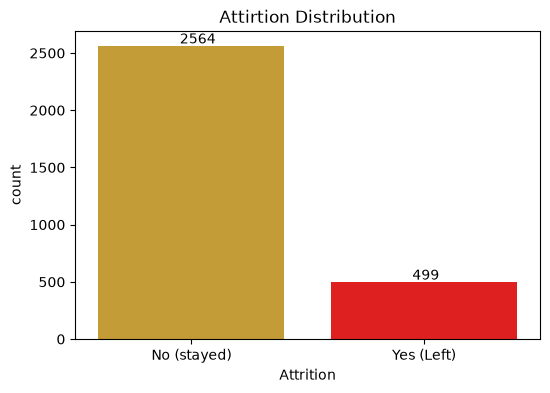

In [13]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "Attrition", data = train_eda , palette = ["goldenrod","red"])
ax.set_xticklabels(["No (stayed)","Yes (Left)"])
plt.title("Attirtion Distribution")
for p in ax.patches:
    ax.annotate(int(p.get_height()),(p.get_x()+0.35,p.get_height()+20))
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\target_distribution.png",dpi=100,bbox_inches="tight")


### Insights

-- Most employees stayed with the company (2,959), while only 569 employees left, showing that employee attrition is relatively low in this dataset.

-- The target variable is imbalanced, so methods like class weighting or resampling should be considered during model training to avoid biased predictions.

\Univariate Analysis

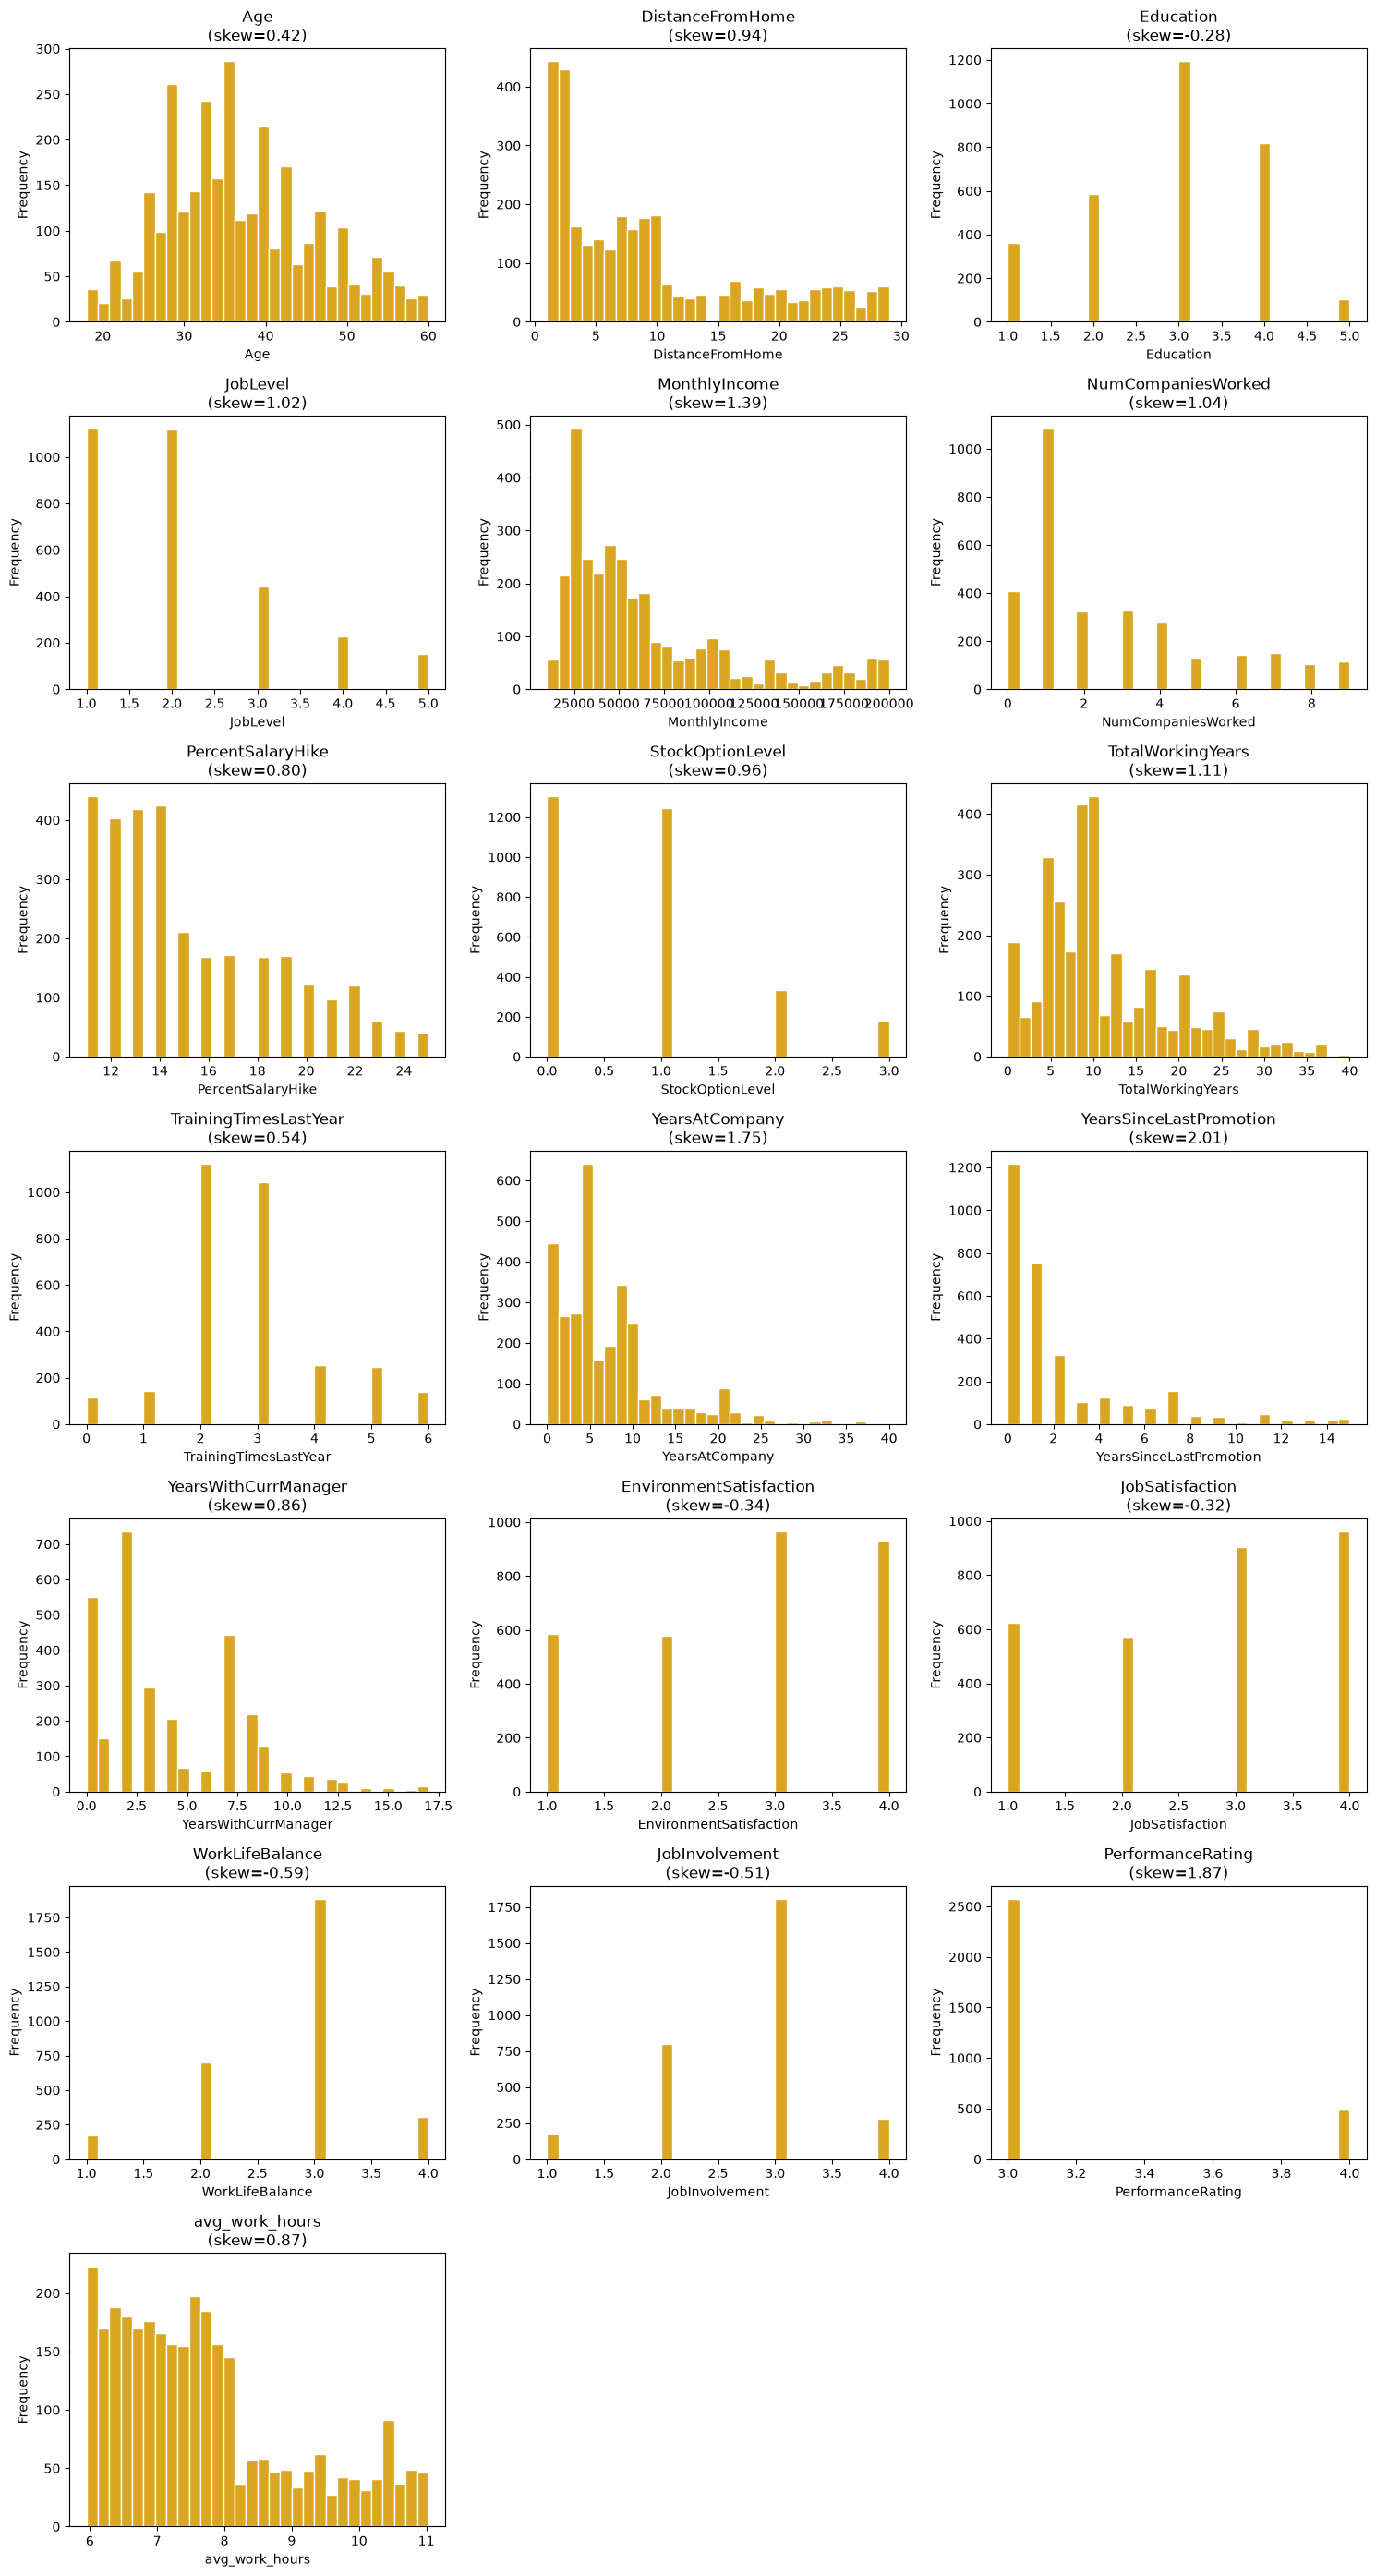

In [14]:
#numeric column analysis
numeric_cols = train_eda.select_dtypes(include=np.number).columns.tolist()
if "Attrition" in numeric_cols:
    numeric_cols.remove("Attrition")

if len(numeric_cols) == 0:
    print("No numeric features to plot.")

n = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols 

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()  

for i, col in enumerate(numeric_cols):
    axes[i].hist(train_eda[col], bins=30, color='goldenrod', edgecolor='white')
    skew = train_eda[col].skew()
    axes[i].set_title(f"{col}\n(skew={skew:.2f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\numeric_distribution.png",dpi=100,bbox_inches="tight")
plt.show()

### Insights

-- Most numerical features are slightly to highly right-skewed, showing that many employees fall into the lower value range while only a few have very high values.

-- Employees are mainly in the age group of 25–40 years, and most have less than 10 years of total work experience.

-- Features like MonthlyIncome, YearsAtCompany, and YearsSinceLastPromotion have a few employees with much higher values than the rest.

-- Variables such as Education, JobLevel, JobSatisfaction, EnvironmentSatisfaction, and WorkLifeBalance are discrete, with only a few fixed categories.

-- Most employees have a Performance Rating of 3, while only a small number have a rating of 4, indicating an uneven distribution.

-- The average working hours are mostly between 6 and 8 hours, with only a few employees working significantly longer.

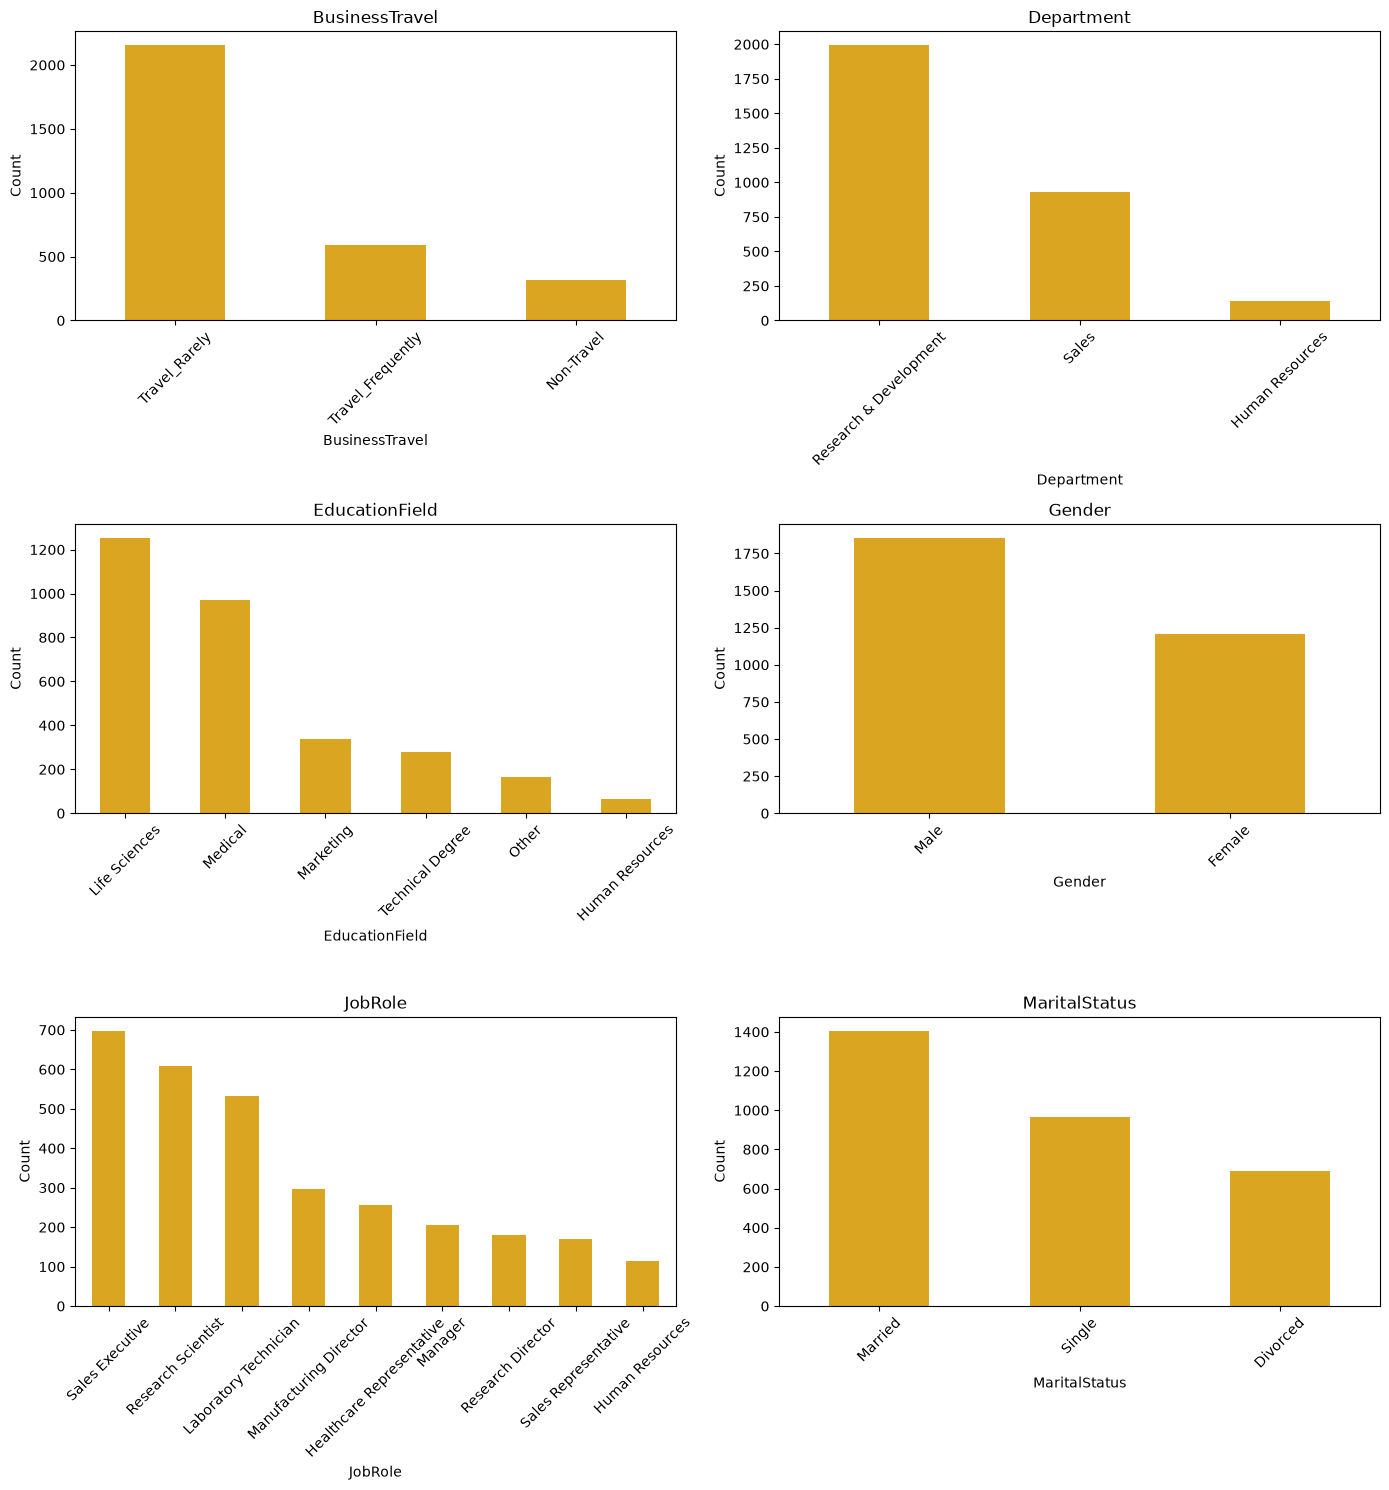

In [15]:
#categorical coln analysis
cat_cols = train_eda.select_dtypes(include="object").columns.tolist()
if "Attrition" in cat_cols:
    cat_cols.remove("Attrition")

if len(cat_cols) == 0:
    print("No suitable categorical features to plot.")
    
n = len(cat_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    train_eda[col].value_counts().plot(kind="bar", ax=axes[i], color="goldenrod")
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\categorical_distribution.png",dpi=100,bbox_inches="tight")
plt.show()


### Insights

-- Most employees travel rarely for work, while only a smaller group travels frequently or does not travel at all.

-- The majority of employees work in the Research & Development department, followed by Sales, with Human Resources having the fewest employees.

-- Most employees have an education background in Life Sciences or Medical, while the other education fields have fewer employees.

-- The workforce has more male employees than female employees, indicating a moderate gender imbalance in the dataset.

-- The most common job roles are Sales Executive, Research Scientist, and Laboratory Technician, while Human Resources has the smallest representation.

-- Most employees are married, followed by single employees, while divorced employees make up the smallest group.

\Bivariate Analysis

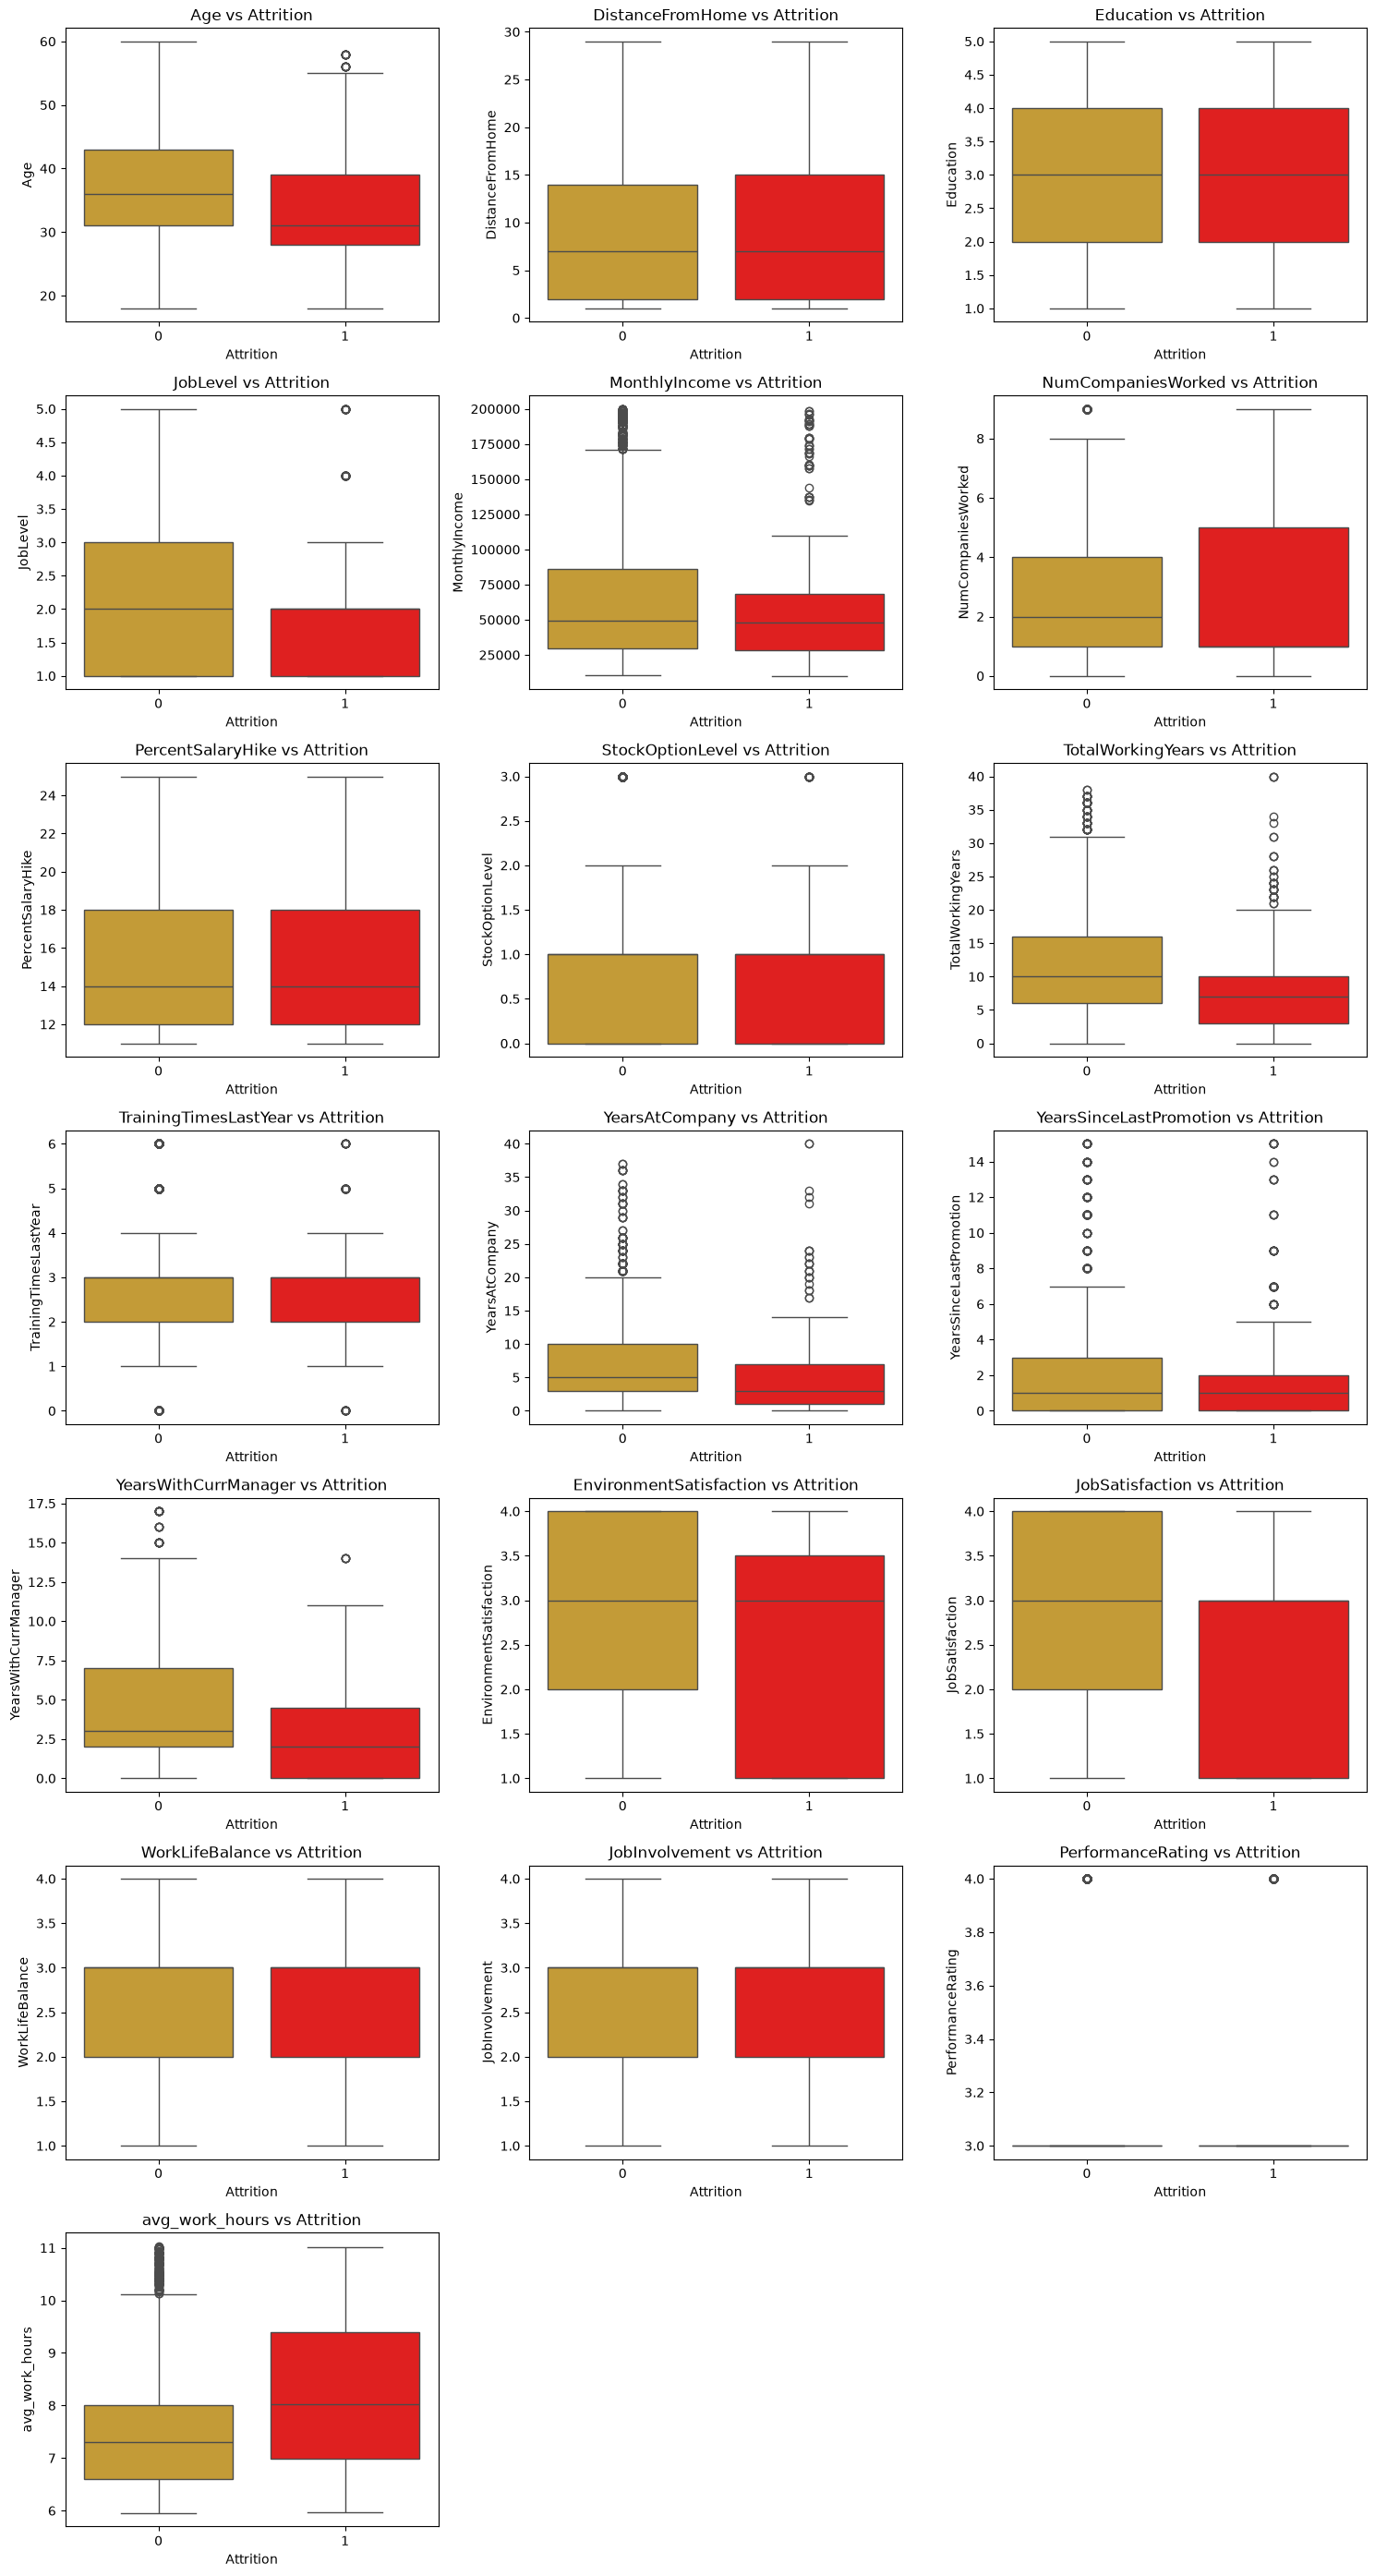

In [16]:
#numeric vs attrition analysis
numeric_cols = train_eda.select_dtypes(include=np.number).columns.tolist()
if "Attrition" in numeric_cols:
    numeric_cols.remove("Attrition")

if len(numeric_cols) == 0:
    print("No numeric features to plot.")

n = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()  

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        x="Attrition",
        y=col,
        data=train_eda,
        palette=["goldenrod", "red"],
        ax=ax
    )
    ax.set_title(f"{col} vs Attrition")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\numeric_vs_attrition.png",dpi=100,bbox_inches="tight")
plt.show()

### Insights

-- Employees who left the company are generally younger and have fewer total working years compared to those who stayed.

-- Employees with lower job levels and fewer years at the company show a higher chance of leaving.

-- People who travel longer distances to work and work more hours on average seem to leave more often.

-- Employees who left have slightly lower environment satisfaction and job satisfaction, which may have influenced their decision.

-- Monthly income, education level, salary hike, work-life balance, and performance rating do not show a strong difference between employees who stayed and those who left.

-- Overall, experience, job level, working hours, and satisfaction appear to have a bigger impact on employee attrition than salary or education.

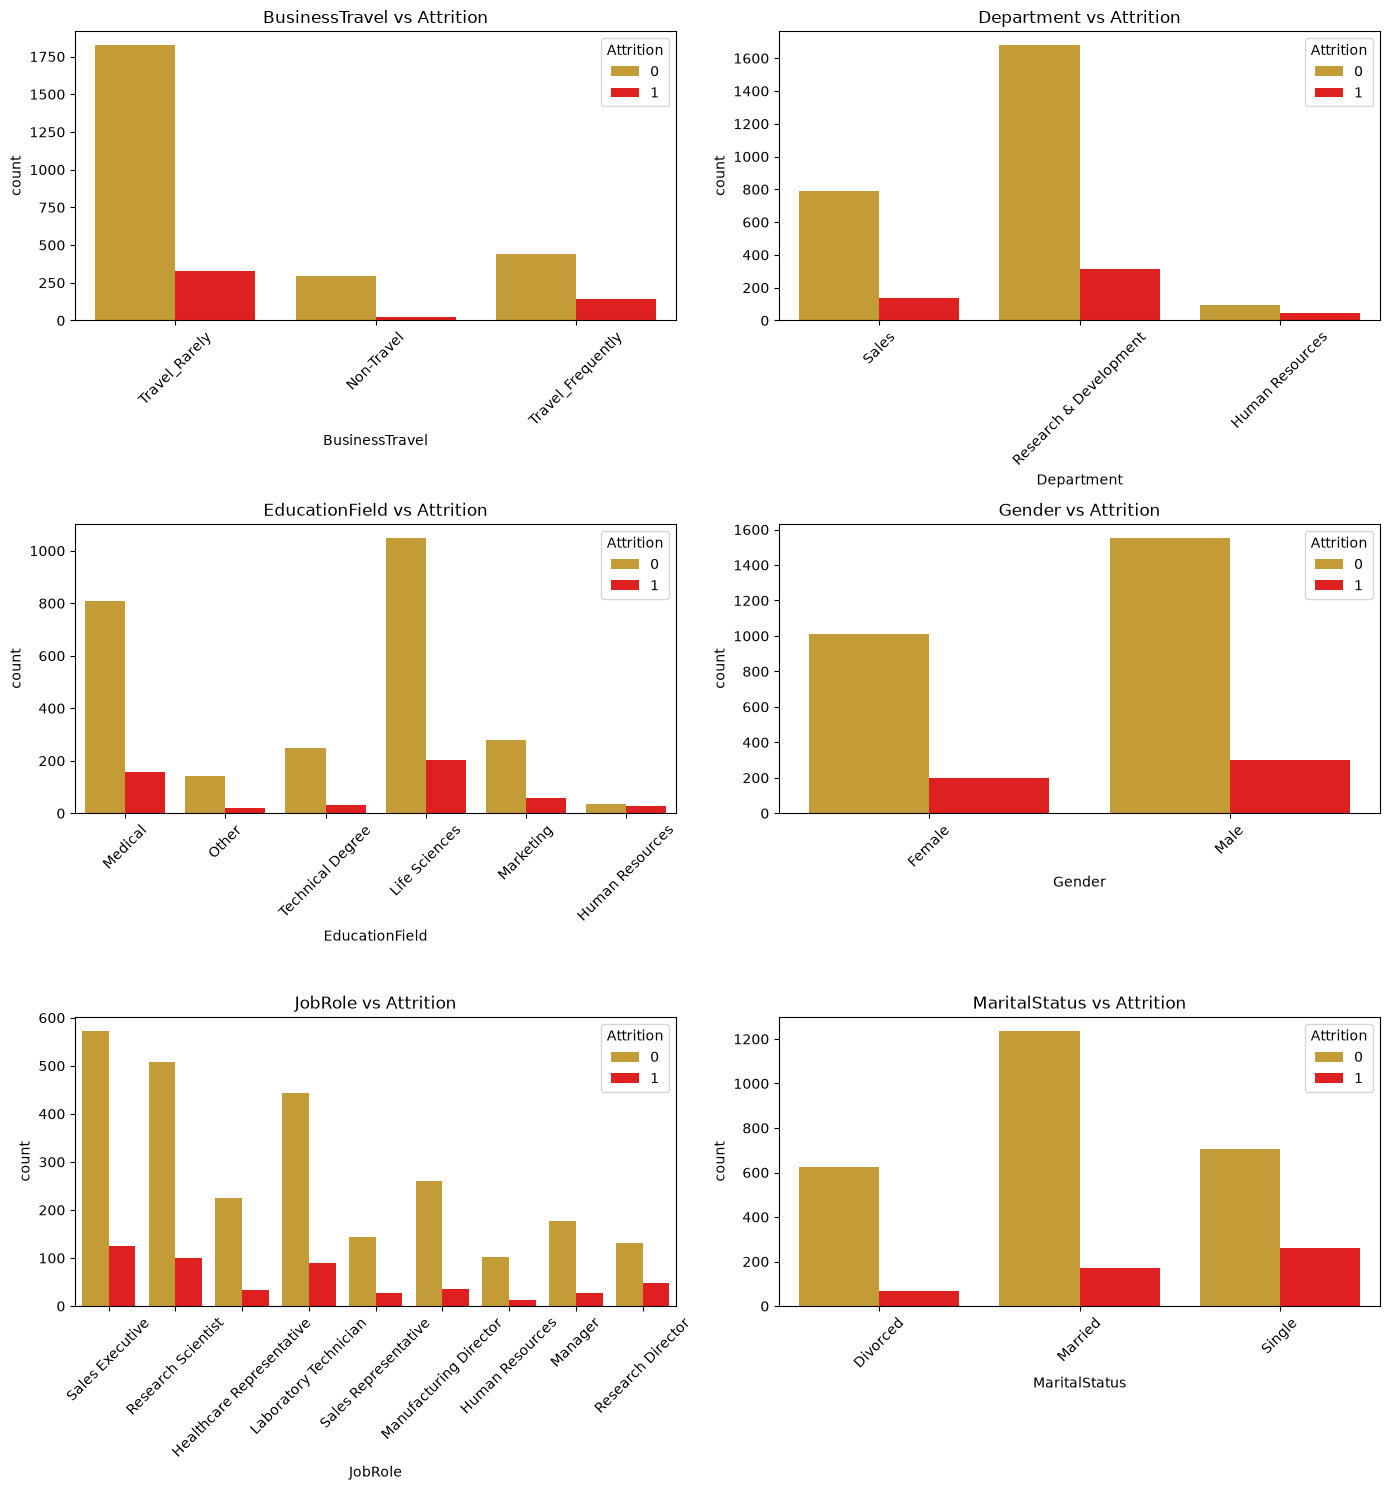

In [17]:
#categorical vs attrition analysis
cat_cols = train_eda.select_dtypes(include="object").columns.tolist()
if "Attrition" in cat_cols:
    cat_cols.remove("Attrition")

if len(cat_cols) == 0:
    print("No suitable categorical features to plot.")
    
n = len(cat_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(
        data=train_eda,
        x=col,
        hue="Attrition",
        palette=["goldenrod", "red"],
        ax=ax
    )
    ax.set_title(f"{col} vs Attrition")
    ax.tick_params(axis='x', rotation=45)

for j in range(n, len(axes)):
    axes[j].set_visible(False)
        
plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\categorical_vs_attrition.png", dpi=100, bbox_inches='tight')
plt.show()

### Insights

-- Employees who travel frequently for work have a higher attrition rate than those who travel rarely or do not travel.

-- The Research & Development department has the highest number of employees leaving, mainly because it has the largest workforce. Sales also shows a noticeable number of exits.

-- Employees from the Life Sciences and Medical education fields account for most attrition, while other education fields have fewer employees leaving.

-- Male employees have a slightly higher number of resignations than female employees, but this also reflects the higher number of male employees in the company.

-- Sales Executives, Research Scientists, and Laboratory Technicians show the highest employee turnover among all job roles.

-- Single employees leave the company more often than married or divorced employees, suggesting marital status may have some influence on attrition.

\correlation Analysis

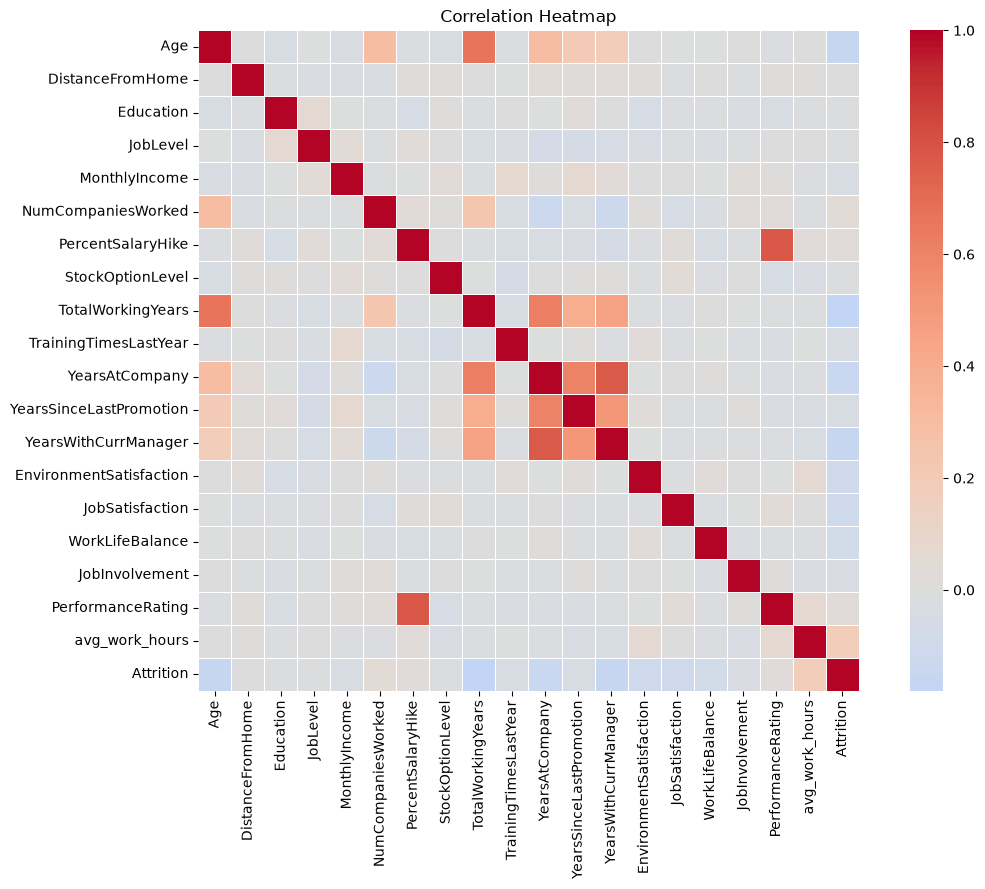

Top features correlated with 'Attrition':
  avg_work_hours: 0.188
  TotalWorkingYears: 0.180
  YearsWithCurrManager: 0.159
  Age: 0.154
  YearsAtCompany: 0.145
  EnvironmentSatisfaction: 0.105
  JobSatisfaction: 0.103
  WorkLifeBalance: 0.079
  NumCompaniesWorked: 0.045
  MonthlyIncome: 0.044


In [18]:
numeric_df = train_eda.select_dtypes(include=np.number)

if numeric_df.shape[1]<2:
    print("Need atleast 2 numeric columns for correlation")
    
corr = numeric_df.corr()

fig,ax = plt.subplots(figsize=(12,9))
sns.heatmap(corr,annot=False,cmap="coolwarm",center=0,square=True,linewidths=0.5,ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\correlation_analysis.png", dpi=100, bbox_inches='tight')
plt.show()

if "Attrition" is not None and "Attrition" in numeric_df.columns:
    Attrition_corr = corr["Attrition"].drop("Attrition").abs().sort_values(ascending=False)
    print(f"Top features correlated with '{"Attrition"}':")
    for col ,val in Attrition_corr.head(10).items():
        print(f"  {col}: {val:.3f}")

### Insights

-- Most features have a weak correlation with attrition, showing that employee turnover is influenced by multiple factors rather than a single variable.

-- Total Working Years, Years at Company, Years with Current Manager, and Years Since Last Promotion are positively correlated, as they all relate to employee experience.

-- Age is positively related to Total Working Years, indicating that older employees generally have more work experience.

-- Average work hours show a slight positive correlation with attrition, while experience-related features have a slight negative correlation with attrition.

### Feature Engineering

In [19]:
def add_engineered_features(data):
    
    d = data.copy()
    
    d['TenureRatio']      = d['YearsAtCompany'] / (d['TotalWorkingYears'] + 1)
    d['PromotionGap']     = d['YearsSinceLastPromotion'] / (d['YearsAtCompany'] + 1)
    d['IncomePerYear']    = d['MonthlyIncome'] / (d['TotalWorkingYears'] + 1)
    d['IsOverworked']     = (d['avg_work_hours'] > 8).astype(int)
    d['ManagerStability'] = d['YearsWithCurrManager'] / (d['YearsAtCompany'] + 1)
    
    return d

# Apply to both sets
X_train = add_engineered_features(X_train)
X_test  = add_engineered_features(X_test)

print("Feature engineering done ")
print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("\nNew features preview:")
X_train[['TenureRatio','PromotionGap','IncomePerYear','IsOverworked','ManagerStability']].sample(10)

Feature engineering done 
X_train shape: (3063, 30)
X_test  shape: (766, 30)

New features preview:


,TenureRatio,PromotionGap,IncomePerYear,IsOverworked,ManagerStability
1674,0.727273,0.444444,3108.181818,1,0.777778
3687,0.909091,0.818182,14843.636364,0,0.818182
2114,0.800000,0.777778,6811.000000,1,0.777778
2243,0.909091,0.272727,4606.363636,0,0.818182
3224,0.888889,0.040000,1594.814815,1,0.440000
2966,0.909091,0.636364,2610.000000,1,0.727273
2629,0.375000,0.000000,3896.250000,0,0.250000
524,0.750000,0.000000,22875.000000,0,0.285714
2784,0.500000,0.125000,772.142857,0,0.875000
2506,0.857143,0.000000,23460.000000,1,0.428571


In [20]:
check = X_train[['TenureRatio','PromotionGap','IncomePerYear',
                 'IsOverworked','ManagerStability']].copy()
check['Attrition'] = y_train.values

print("New features — correlation with Attrition:")
print(check.corr()["Attrition"].drop('Attrition').sort_values())

New features — correlation with Attrition:
ManagerStability   -0.155190
TenureRatio        -0.085268
PromotionGap       -0.004085
IncomePerYear       0.116550
IsOverworked        0.209961
Name: Attrition, dtype: float64


\Checking multicollinearity

In [21]:
corr_matrix =X_train.select_dtypes(include=np.number).corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))

high_corr = [(c,r,round(upper.loc[r,c],3))
             for c in upper.columns for r in upper.index
             if upper.loc[r,c]>0.85]

print("Highly correlated pairs (>0.85):")
if high_corr:
    for a, b, v in high_corr:
        print(f"  {b}  <->  {a}  =  {v}")
else:
    print("  None found ")

Highly correlated pairs (>0.85):
  None found 


### Insights

-- No highly correlated feature pairs (correlation > 0.85) were found, indicating that multicollinearity is not a significant concern in the dataset.

\Feature Encoding

In [22]:
encoders = {}
report = {"binary_encoded": [], "onehot_encoded": [], "freq_encoded": []}

cat_cols = X_train.select_dtypes(include="object").columns.tolist()

binary_cols   = [c for c in cat_cols if X_train[c].nunique() == 2]
onehot_cols   = [c for c in cat_cols if 2 < X_train[c].nunique() <= 10]
highcard_cols = [c for c in cat_cols if X_train[c].nunique() > 10]


freq_maps = {}
for col in highcard_cols:
    freq = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq).fillna(0)
    X_test[col]  = X_test[col].map(freq).fillna(0)
    freq_maps[col] = freq.to_dict()
if freq_maps:
    encoders["__freq_maps__"] = freq_maps
    report["freq_encoded"] = highcard_cols

for col in binary_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])
    encoders[col] = le
    report["binary_encoded"].append(col)

if onehot_cols:
    X_train = pd.get_dummies(X_train, columns=onehot_cols, drop_first=False)
    X_test  = pd.get_dummies(X_test,  columns=onehot_cols, drop_first=False)

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    bool_cols = X_train.select_dtypes(include="bool").columns
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols]  = X_test[bool_cols].astype(int)

    report["onehot_encoded"] = onehot_cols

report["final_shape_train"] = X_train.shape
report["final_shape_test"]  = X_test.shape

In [23]:
print("Binary encoded  :", report["binary_encoded"])
print("One-hot encoded :", report["onehot_encoded"])
print("Freq encoded    :", report["freq_encoded"])
print("Final train shape:", report["final_shape_train"])
print("Final test shape :", report["final_shape_test"])
print("\nColumns after encoding:")
print(X_train.columns.tolist())


Binary encoded  : ['Gender']
One-hot encoded : ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
Freq encoded    : []
Final train shape: (3063, 49)
Final test shape : (766, 49)

Columns after encoding:
['Age', 'DistanceFromHome', 'Education', 'Gender', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_work_hours', 'TenureRatio', 'PromotionGap', 'IncomePerYear', 'IsOverworked', 'ManagerStability', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', '

### Insights

-- The categorical features were successfully converted into numerical format using binary encoding for Gender and one-hot encoding for the remaining categorical variables. No frequency encoding was required because none of the features had high cardinality.

-- After encoding, the dataset increased to 49 features, while the train and test sets maintained the same feature structure, making them ready for model training without any data leakage.

\Feature Scaling

In [24]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
scale_cols = [
c for c in numeric_cols
if c != "Attrition" and X_train[c].nunique() >= 10
]

if len(scale_cols) == 0:
    print("No continuous numeric columns to scale.")

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
print(f"Scaled (fit-transform) {len(scale_cols)} columns: {scale_cols}")
X_test[scale_cols] = scaler.transform(X_test[scale_cols])
print(f"Scaled (transform) {len(scale_cols)} columns using existing scaler")

Scaled (fit-transform) 14 columns: ['Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'avg_work_hours', 'TenureRatio', 'PromotionGap', 'IncomePerYear', 'ManagerStability']
Scaled (transform) 14 columns using existing scaler


### Insights

-- The numerical features were standardized using the scaler fitted on the training data, ensuring that all features are on a similar scale for model training.

-- The same fitted scaler was applied to the test data without refitting, preventing data leakage and maintaining consistency between the training and test datasets.

In [25]:
X_train.head()

,Age,DistanceFromHome,Education,Gender,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,avg_work_hours,TenureRatio,PromotionGap,IncomePerYear,IsOverworked,ManagerStability,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
619,1.005345,-0.035565,1,0,1,1.644705,-0.276838,1.825480,0,0.103526,3,-0.155278,-0.362685,-0.025315,4.0,4.0,2.0,3,4,-1.095501,-0.422790,-0.344829,0.187937,0,0.382090,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0
1186,2.100583,0.086561,4,1,2,-0.507717,2.111769,2.367550,1,0.362383,3,0.508063,2.131625,1.098456,4.0,3.0,1.0,3,4,-0.645867,0.296606,2.157077,-0.489164,0,0.944006,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0
2272,-0.527988,-0.524070,4,1,5,-0.309411,-1.073041,-0.613832,0,-0.155331,5,0.342228,-0.362685,0.536570,4.0,2.0,2.0,3,3,-0.818227,0.827979,-0.503604,-0.337006,0,0.485108,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0
3476,-0.308941,-1.012575,2,0,2,2.405128,-1.073041,-1.155902,0,-0.673046,5,-0.321113,-0.362685,-0.587200,4.0,4.0,3.0,2,3,1.677241,0.463609,-0.256621,1.383543,1,-0.476392,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0
3810,1.662487,-0.890449,3,1,1,-0.415746,-0.674939,-0.342797,0,2.821527,3,4.322271,4.002358,2.222226,1.0,3.0,4.0,2,3,0.845418,1.362477,0.760368,-0.605024,1,-0.405693,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1


\class weight checking

In [26]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', 
                               classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights.round(3)))

print("Train distribution (UNCHANGED — no resampling):")
print(y_train.value_counts().to_dict())
print("Ratio:", (y_train.value_counts(normalize=True)*100).round(2).to_dict())

print("\nClass weights that will be applied later:")
print(class_weight_dict)
print("\n→ Class 1 (Yes/Attrition) gets ~5x more importance")

# For XGBoost 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nXGBoost scale_pos_weight = {scale_pos_weight:.2f}")

Train distribution (UNCHANGED — no resampling):
{0: 2564, 1: 499}
Ratio: {0: 83.71, 1: 16.29}

Class weights that will be applied later:
{np.int64(0): np.float64(0.597), np.int64(1): np.float64(3.069)}

→ Class 1 (Yes/Attrition) gets ~5x more importance

XGBoost scale_pos_weight = 5.14


### Insights

-- The training data remained imbalanced, with about 84% employees staying and 16% leaving, and no resampling was performed to preserve the original data distribution.

-- To address this imbalance, class weights and XGBoost's scale_pos_weight will be used, giving higher importance to the minority (Attrition) class during model training.

\Saving the processed dataset

In [27]:
X_train.to_csv(r"C:\NG\Employee Attrition Prediction\data\processed\X_train.csv",index=False)
X_test.to_csv(r"C:\NG\Employee Attrition Prediction\data\processed\X_test.csv",index=False)
y_train.to_csv(r"C:\NG\Employee Attrition Prediction\data\processed\y_train.csv",index=False)
y_test.to_csv(r"C:\NG\Employee Attrition Prediction\data\processed\y_test.csv",index=False)

print("Processed data saved")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Processed data saved
X_train: (3063, 49)
X_test : (766, 49)
y_train: (3063,)
y_test : (766,)


\Saving preprocessing object

In [28]:
preprocessing_objects = {
    'fill_values': fill_values,        
    'encoder': encoders,                
    'scaler': scaler,                  
    'cat_cols': cat_cols,              
    'scale_cols': scale_cols,          
    'drop_cols': drop_cols,            
    'feature_order': list(X_train.columns)
}

joblib.dump(preprocessing_objects,r"C:\NG\Employee Attrition Prediction\models\preprocessing_objects.pkl")

print("Preprocessing objects saved ")
print("\nSaved keys:")
for k in preprocessing_objects.keys():
    print("  -", k)
print("\nTotal features model expects:", len(preprocessing_objects['feature_order']))

Preprocessing objects saved 

Saved keys:
  - fill_values
  - encoder
  - scaler
  - cat_cols
  - scale_cols
  - drop_cols
  - feature_order

Total features model expects: 49
